In [3]:
import pandas as pd

# Path to saved regime csv
path = '/Users/developmentserver/Desktop/regime_xlk.csv'

df = pd.read_csv(path) 
df

FileNotFoundError: [Errno 2] No such file or directory: '/Users/developmentserver/Desktop/regime_xlk.csv'

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import yfinance as yf


def plot_regime_forecast(
    results: pd.DataFrame,
    ticker: str,
    feature_set: str = 'returns',
    regime_labels: list[str] | None = None,
    start: str | None = None,
    end: str | None = None,
    figsize: tuple = (14, 8),
) -> None:
    # ── Normalise index ──────────────────────────────────────────────────────
    df = results.copy()
    if 'date' in df.columns:
        df = df.set_index('date')
    df.index = pd.to_datetime(df.index)

    # ── Date filter ─────────────────────────────────────────────────────────
    if start:
        df = df.loc[start:]
    if end:
        df = df.loc[:end]

    if df.empty:
        raise ValueError(f'No data in range [{start}, {end}]')

    k = int(df['forecast_regime'].max()) + 1
    if regime_labels is None:
        regime_labels = [f'Regime {i}' for i in range(k)]

    if feature_set == 'macro':
        colors = ['#2ecc71', '#f39c12', '#e74c3c'][:k]
    else:
        colors = ['#e74c3c', '#f39c12', '#2ecc71'][:k]

    # ── Fetch monthly close (scoped to filtered range) ───────────────────────
    fetch_start = df.index[0].strftime('%Y-%m-%d')
    fetch_end   = df.index[-1].strftime('%Y-%m-%d')
    raw   = yf.download(ticker, start=fetch_start, end=fetch_end, auto_adjust=True, progress=False)
    price = raw['Close'].resample('ME').last().dropna()

    # ── Layout ───────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.04},
    )

    # ── Top: price + regime shading ──────────────────────────────────────────
    ax1.plot(price.index, price.values, color='#1a252f', linewidth=1.2, zorder=3)
    ax1.set_yscale('log')
    ax1.set_ylabel('Price  (log scale)', fontsize=11)

    date_range_str = f'{fetch_start} → {fetch_end}'
    ax1.set_title(f'{ticker}  —  HMM Forecast Regime  ({date_range_str})', fontsize=13, fontweight='bold')
    ax1.grid(axis='y', linestyle='--', alpha=0.35)

    dates   = df.index.tolist()
    regimes = df['forecast_regime'].tolist()

    for i, (x0, reg) in enumerate(zip(dates, regimes)):
        x1 = dates[i + 1] if i + 1 < len(dates) else x0 + pd.DateOffset(months=1)
        ax1.axvspan(x0, x1, alpha=0.22, color=colors[reg], zorder=1)

    patches = [
        mpatches.Patch(color=colors[i], alpha=0.7, label=regime_labels[i])
        for i in range(k)
    ]
    ax1.legend(handles=patches, loc='upper left', fontsize=10)

    # ── Bottom: stacked forecast probabilities ───────────────────────────────
    fcast_cols = [f'p{i}_forecast' for i in range(k)]
    prob_arr   = df[fcast_cols].values.T

    ax2.stackplot(df.index, prob_arr, labels=regime_labels, colors=colors, alpha=0.80)
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('Forecast P', fontsize=10)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax2.grid(axis='x', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()


/var/folders/hm/wjf212gn065g66t2hgmj94tc0000gn/T/ipykernel_83367/2035398376.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


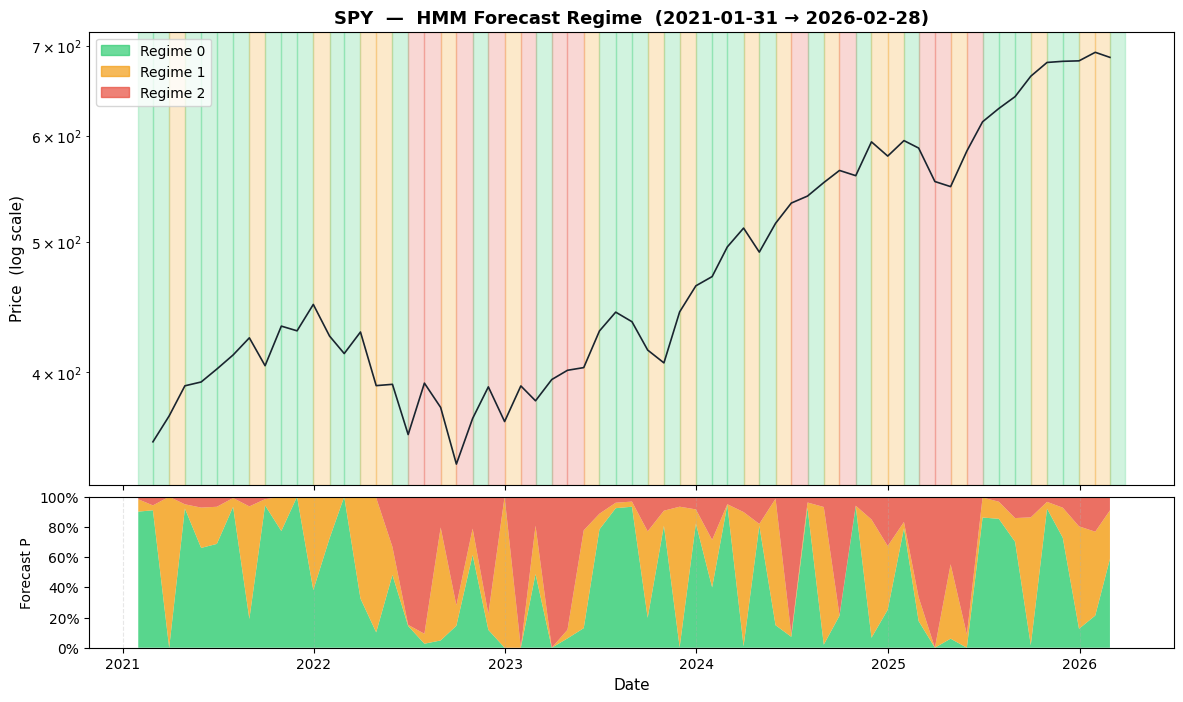

In [13]:
plot_regime_forecast(df, 'SPY', feature_set='macro')   # green=calm, red=stress
# plot_regime_forecast(df, 'SPY', feature_set='returns')  # red=bear, green=bull
# plot_regime_forecast(df, 'SPY', feature_set='rvv')      # red=bear, green=bull


Depending on the feature set, the market regimes will be displayed differently. 

For the feature set of Macro the regime states are as follows:
- Regime 0 - growth/bullish
- Regime 1 - stationary
- Regime 2 - high stress/bear

For returns only or rvv feature sets, the regime states are as follows:
- Regime 0 - bearish
- Regime 1 - stationary
- Regime 2 - bullish 